# Studi Kasus 2: Demografi Pemilik vs Ketahanan Usaha

Notebook ini berfokus menganalisis pola antara profil pemilik (Usia, Jenis Kelamin, Pendidikan) dengan usia UMKM.

**Metode**: K-Means Clustering + Cuckoo Search Algorithm Optimization


In [1]:
import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath("../src"))
from preprocessing import preprocess_demografi
from csa_core import hitung_optimal_k_elbow, cuckoo_search_kmeans, final_kmeans, plot_hasil_cluster, evaluasi_kualitas_klasterisasi

# 1. Preprocessing Data Khusus Skenario
df_raw, df_scaled, list_fitur = preprocess_demografi("data/Data Set UMKM.xlsx")
X_scaled = df_scaled.values

print(f"Data shape: {X_scaled.shape}")
print(f"Fitur: {list_fitur}")
df_raw.head()


Data shape: (2769, 4)
Fitur: ['Usia Pemilik', 'Is_Laki', 'Tingkat Pendidikan', 'Lama Usaha (Tahun)']


,Usia Pemilik,Is_Laki,Tingkat Pendidikan,Lama Usaha (Tahun)
0,42.0,0,2,9.0
1,41.0,0,3,14.0
2,41.0,0,4,6.0
3,53.0,0,3,10.0
4,61.0,0,4,6.0


In [5]:
df_raw

,Usia Pemilik,Is_Laki,Tingkat Pendidikan,Lama Usaha (Tahun),Cluster
0,42.0,0,2,9.0,1
1,41.0,0,3,14.0,1
2,41.0,0,4,6.0,1
3,53.0,0,3,10.0,1
4,61.0,0,4,6.0,1
...,...,...,...,...,...
2764,37.0,1,4,6.0,1
2765,67.0,0,3,9.0,1
2766,68.0,0,2,19.0,1
2767,61.0,1,3,6.0,1



Mencari jumlah klaster (K) optimal...


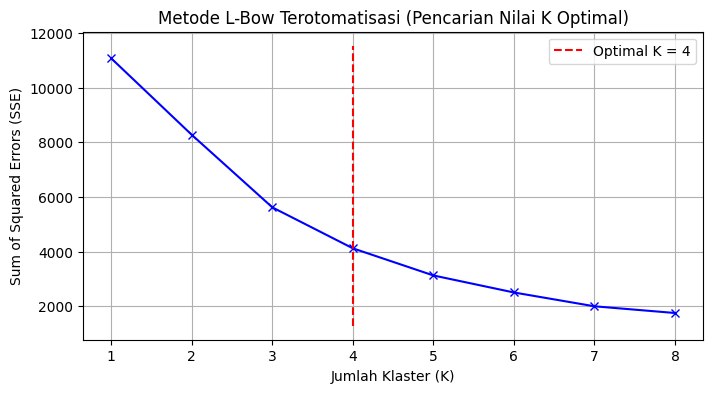

In [2]:
# 2. Mencari K-Optimal secara Otomatis
print("\nMencari jumlah klaster (K) optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=8)


In [3]:
# 3. Proses Training (Fitting) dengan Cuckoo Search Algorithm
print(f"\nMemulai Cuckoo Search dengan K={optimal_k}...")
best_nest, fitness_history = cuckoo_search_kmeans(
    X=X_scaled, 
    k=optimal_k, 
    n_nests=10, 
    max_iter=30, 
    pa=0.25
)

# 4. Fine-Tuning dengan K-Means konvensional
print("\nMelakukan Fine-Tuning K-Means...")
labels, final_centroids = final_kmeans(X_scaled, best_nest)



Memulai Cuckoo Search dengan K=4...

Melakukan Fine-Tuning K-Means...


      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.9557
   [Interpretasi]: SANGAT BAGUS. Data terstruktur dengan kokoh.

2. Davies-Bouldin Index (DBI): 0.0321
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 873.1820
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 8419.1647
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 2.7025
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.

Distribusi Klaster:
Cluster
1    2768
0       1
Name: count, dtype: int64
-> Dimensi 4D terdeteksi! Mengecilkan ke Ruang Visual 3D dengan Principal Component Analysis (PCA).


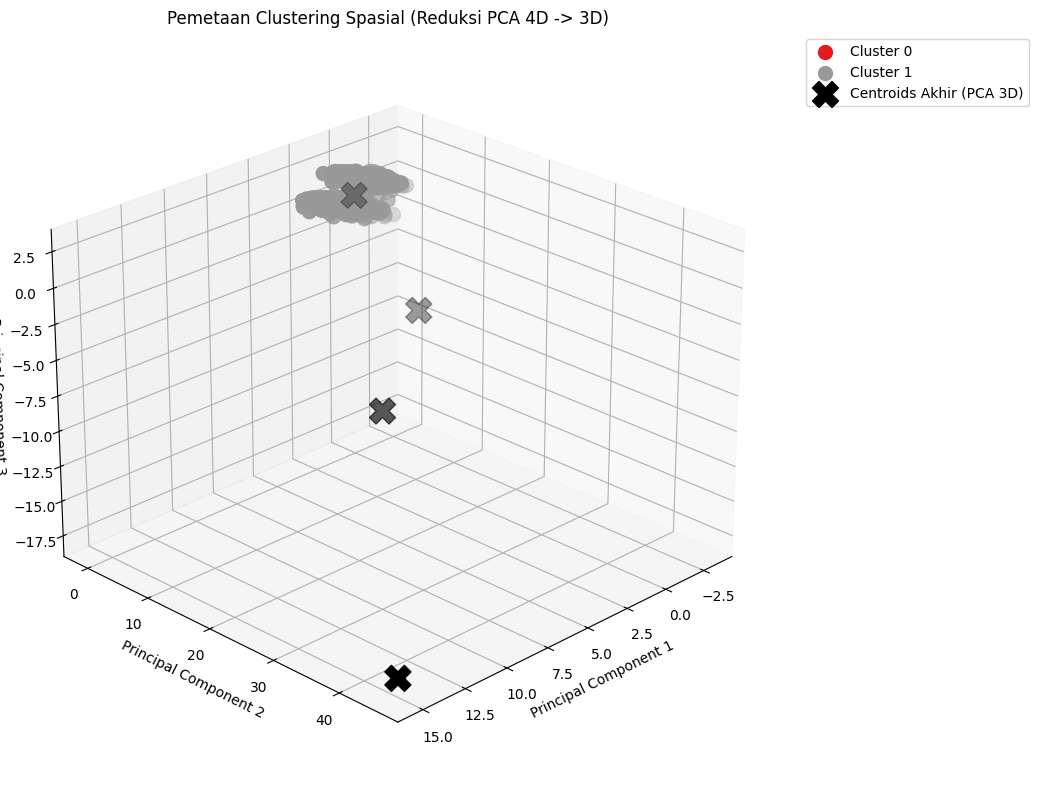

In [4]:
# 5. Evaluasi Metrik & Visualisasi
evaluasi_kualitas_klasterisasi(X_scaled, labels, final_centroids)

# Memasukkan hasil klaster ke dataframe asli
df_raw["Cluster"] = labels
print("\nDistribusi Klaster:")
print(df_raw["Cluster"].value_counts())

# Plot hasil
plot_hasil_cluster(X_scaled, final_centroids, labels, list_fitur)
